In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
data= pd.read_csv(r"C:\Users\Lenovo\OneDrive\Desktop\ft\project\1768456274717-ML Project - Random Forest Hotel Cancellation Prediction Analysis 16955485770.txt")

In [3]:
data.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,01/07/2015
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,01/07/2015
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,02/07/2015
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,02/07/2015
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,03/07/2015


In [4]:
for col in data.columns:
    print(f'\nUnique Values in {col}:')
    print(data[col].unique())


Unique Values in hotel:
['Resort Hotel' 'City Hotel']

Unique Values in is_canceled:
[0 1]

Unique Values in lead_time:
[342 737   7  13  14   0   9  85  75  23  35  68  18  37  12  72 127  78
  48  60  77  99 118  95  96  69  45  40  15  36  43  70  16 107  47 113
  90  50  93  76   3   1  10   5  17  51  71  63  62 101   2  81 368 364
 324  79  21 109 102   4  98  92  26  73 115  86  52  29  30  33  32   8
 100  44  80  97  64  39  34  27  82  94 110 111  84  66 104  28 258 112
  65  67  55  88  54 292  83 105 280 394  24 103 366 249  22  91  11 108
 106  31  87  41 304 117  59  53  58 116  42 321  38  56  49 317   6  57
  19  25 315 123  46  89  61 312 299 130  74 298 119  20 286 136 129 124
 327 131 460 140 114 139 122 137 126 120 128 135 150 143 151 132 125 157
 147 138 156 164 346 159 160 161 333 381 149 154 297 163 314 155 323 340
 356 142 328 144 336 248 302 175 344 382 146 170 166 338 167 310 148 165
 172 171 145 121 178 305 173 152 354 347 158 185 349 183 352 177 200 192
 36

In [5]:
obj_col = data.select_dtypes(include='object').columns

for col in obj_col :
    data[col] = data[col].fillna('other')

In [6]:
data['agent'] = data['agent'].fillna(data['agent'].mean())

In [7]:
data.dropna(inplace=True)

In [8]:
data.shape

(6797, 32)

In [9]:
data.isnull().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
company                           0
days_in_waiting_list              0
customer_type                     0
adr                         

In [11]:
total_adults = data['adults'].sum()
total_children = data['children'].sum()

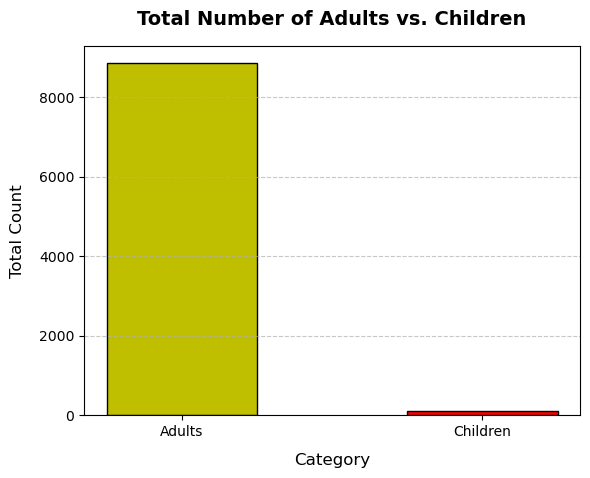

In [47]:
df_totals = pd.DataFrame({
    'Category': ['Adults', 'Children'],
    'Total Count': [total_adults, total_children]
}).sort_values(by='Total Count', ascending=False)
plt.bar(df_totals['Category'], df_totals['Total Count'], color=['y', 'r'], edgecolor='black', width=0.5)

plt.title('Total Number of Adults vs. Children', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Category', fontsize=12, labelpad=10)
plt.ylabel('Total Count', fontsize=12, labelpad=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

In [16]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = data.select_dtypes(include=['object']).columns
le = LabelEncoder()

for col in categorical_cols:
    data[col] = le.fit_transform(data[col].astype(str))
    
data.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
18,1,0,0,2015,5,27,1,0,1,2,...,0,86.693382,110.0,0,2,107.42,0,0,1,32
218,1,1,1,2015,5,28,8,0,1,2,...,0,86.693382,110.0,0,2,104.72,0,1,0,172
219,1,1,1,2015,5,28,8,0,1,2,...,0,86.693382,110.0,0,2,104.72,0,1,0,172
220,1,0,1,2015,5,28,8,0,2,2,...,0,86.693382,110.0,0,2,104.72,1,1,1,221
295,1,0,84,2015,5,28,11,1,1,2,...,0,86.693382,113.0,0,2,100.00,1,0,1,289


 # Part 2: Model Building


In [18]:
data.head(13)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
18,1,0,0,2015,5,27,1,0,1,2,...,0,86.693382,110.0,0,2,107.42,0,0,1,32
218,1,1,1,2015,5,28,8,0,1,2,...,0,86.693382,110.0,0,2,104.72,0,1,0,172
219,1,1,1,2015,5,28,8,0,1,2,...,0,86.693382,110.0,0,2,104.72,0,1,0,172
220,1,0,1,2015,5,28,8,0,2,2,...,0,86.693382,110.0,0,2,104.72,1,1,1,221
295,1,0,84,2015,5,28,11,1,1,2,...,0,86.693382,113.0,0,2,100.00,1,0,1,289
387,1,0,1,2015,5,29,14,0,1,1,...,0,86.693382,270.0,0,2,134.00,0,0,1,337
450,1,1,12,2015,5,29,16,2,3,2,...,0,86.693382,178.0,0,2,139.00,0,0,0,148
541,1,0,0,2015,5,30,19,1,0,2,...,0,86.693382,240.0,0,1,88.20,0,0,1,458
600,1,0,5,2015,5,30,21,0,2,1,...,0,86.693382,154.0,0,2,99.50,0,0,1,528
628,1,1,19,2015,5,30,23,1,3,2,...,0,86.693382,178.0,0,2,139.00,0,0,0,148


In [42]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,accuracy_score,precision_score,recall_score,confusion_matrix

In [43]:
X = data.drop(columns=['is_canceled', 'reservation_status'], errors='ignore')
y = data['is_canceled']

In [36]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [37]:
model.score(x_train,y_train)

0.7347802096744528

In [38]:
model.score(x_test,y_test)

0.7323529411764705

In [46]:
y_pred = model.predict(x_test)

print("classification_report :",classification_report(y_test, y_pred))
print("precision_score :",precision_score(y_test, y_pred))
print("recall_score :",recall_score(y_test, y_pred))
print("confusion_matrix :",confusion_matrix(y_test, y_pred))

classification_report :               precision    recall  f1-score   support

           0       0.80      0.89      0.84      1095
           1       0.16      0.09      0.12       265

    accuracy                           0.73      1360
   macro avg       0.48      0.49      0.48      1360
weighted avg       0.68      0.73      0.70      1360

precision_score : 0.16326530612244897
recall_score : 0.09056603773584905
confusion_matrix : [[972 123]
 [241  24]]
